# MRCP Evoked Potential — All Subjects

Epoch the EEG time-locked to each button press, average across repetitions,
and plot the grand average per subject.  
Window: −1500 ms to +500 ms around onset (t = 0 = press).  
Filter: 0.5–8 Hz (MRCP band) + CAR. No decimation (FS = 250 Hz).

In [2]:
import sys, glob, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

from src.preprocessing import load_trial

In [7]:
# ── Config ────────────────────────────────────────────────────────────────────
TACHE    = 'gng'
FS       = 250           # no decimation — full resolution for ERP
LP, HP   = 0.5, 28.0     # MRCP band
PRE_MS   = 500          # ms before press
POST_MS  = 500           # ms after press
PRE      = int(PRE_MS  / 1000 * FS)   # samples
POST     = int(POST_MS / 1000 * FS)   # samples
SUBJECTS = [0, 16, 17]#list(range(10))
TIME_AX  = np.linspace(-PRE_MS, POST_MS, PRE + POST)  # ms

print(f'Epoch: −{PRE_MS} ms to +{POST_MS} ms  ({PRE+POST} samples at {FS} Hz)')

Epoch: −500 ms to +500 ms  (250 samples at 250 Hz)


In [8]:
def available_trials(subj):
    files = glob.glob(f'../data/subject{subj}/subject_{subj}_tache_{TACHE}_trial_*.csv')
    return sorted(int(f.split('trial_')[1].replace('.csv','')) for f in files)


def press_onsets(button_arr):
    """Return sample indices where button transitions 0→1."""
    arr = np.asarray(button_arr)
    diff = np.diff(arr, prepend=arr[0])
    return np.where(diff > 0)[0]


def extract_epochs(X, onsets, pre, post):
    """
    X       : (T, C) array
    onsets  : 1-D array of onset sample indices
    Returns : (n_epochs, pre+post, C) — only epochs fully inside the recording
    """
    epochs = []
    for onset in onsets:
        start, end = onset - pre, onset + post
        if start >= 0 and end <= len(X):
            epochs.append(X[start:end])
    return np.stack(epochs) if epochs else np.empty((0, pre + post, X.shape[1]))

In [9]:
# ── Load and epoch all trials for every subject ───────────────────────────────
subject_erps = {}   # subj -> (pre+post, C) mean ERP
subject_n    = {}   # subj -> total epoch count
EEG_COLS     = None

for subj in SUBJECTS:
    data_path = f'../data/subject{subj}/'
    trials = available_trials(subj)
    if not trials:
        print(f'Subject {subj}: no trials found, skipping')
        continue

    all_epochs = []
    for t in trials:
        df, cols = load_trial(subj, TACHE, t, data_path,
                              eeg_cols=EEG_COLS, fs=FS, lp=LP, hp=HP,
                              decimate=1, car=True, despike_sigma=5, clip_percentile=1)
        if EEG_COLS is None:
            EEG_COLS = cols
        X      = df[EEG_COLS].values.astype(np.float32)
        onsets = press_onsets(df['button'].values)
        epochs = extract_epochs(X, onsets, PRE, POST)
        all_epochs.append(epochs)

    if not all_epochs:
        continue
    all_epochs = np.concatenate(all_epochs, axis=0)   # (N, T, C)

    # Baseline-correct each epoch: subtract mean of pre-stimulus period
    baseline = all_epochs[:, :PRE, :].mean(axis=1, keepdims=True)  # (N,1,C)
    all_epochs = all_epochs - baseline

    subject_erps[subj] = all_epochs.mean(axis=0)   # (T, C)
    subject_n[subj]    = len(all_epochs)
    print(f'Subject {subj}: {len(trials)} trials, {len(all_epochs)} epochs')

N_CH = len(EEG_COLS)
print(f'\n{len(subject_erps)} subjects loaded, {N_CH} channels: {EEG_COLS}')

Subject 0: 12 trials, 357 epochs
Subject 16: 10 trials, 301 epochs
Subject 17: 13 trials, 393 epochs

3 subjects loaded, 16 channels: ['ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7', 'ch8', 'ch9', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15', 'ch16']


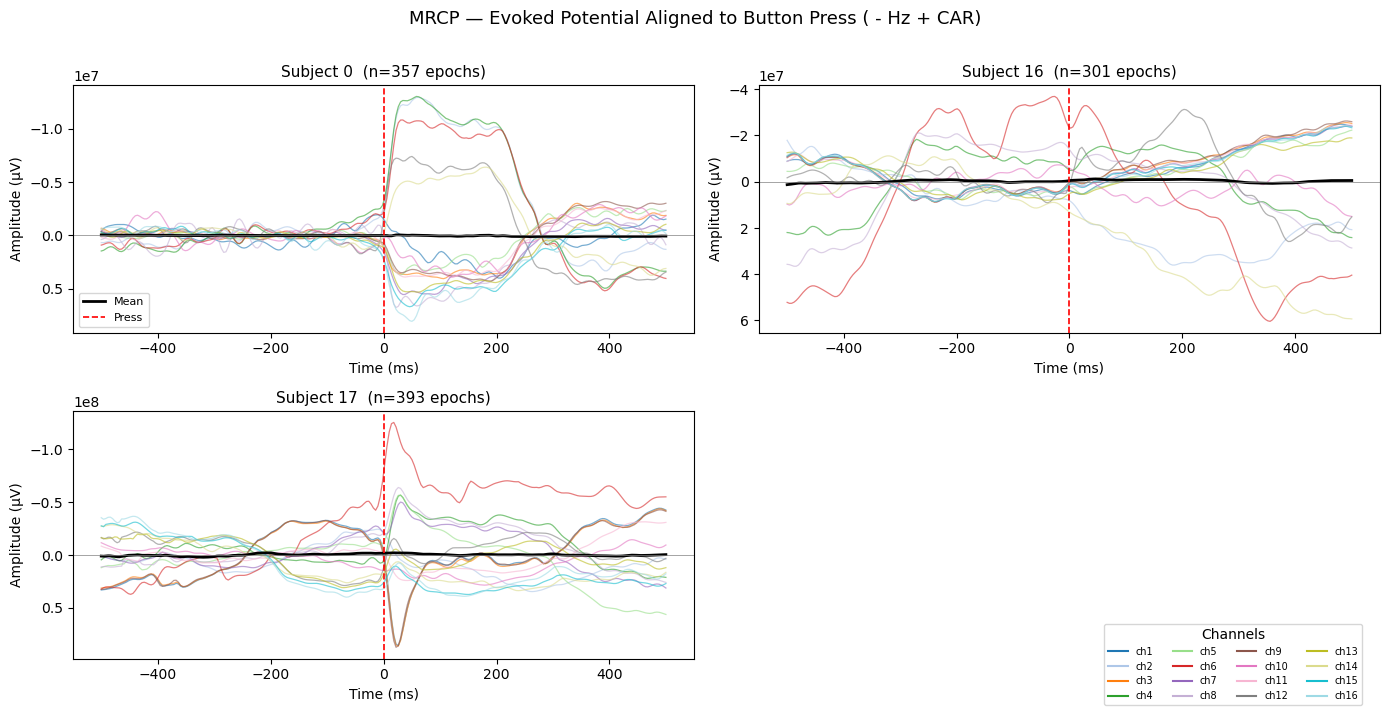

Saved: report/erp_per_subject.png


In [10]:
# ── Per-subject ERP — all channels overlaid ───────────────────────────────────
n_subj = len(subject_erps)
ncols  = 2
nrows  = (n_subj + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5), sharey=False)
axes = axes.flatten()

cmap = plt.cm.tab20(np.linspace(0, 1, N_CH))

for ax_idx, (subj, erp) in enumerate(sorted(subject_erps.items())):
    ax = axes[ax_idx]
    for ch in range(N_CH):
        ax.plot(TIME_AX, erp[:, ch] * 1e6, alpha=0.6, lw=0.9, color=cmap[ch])
    # Mean across channels
    ax.plot(TIME_AX, erp.mean(axis=1) * 1e6, color='black', lw=2, label='Mean')
    ax.axvline(0, color='red', lw=1.2, ls='--', label='Press')
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_title(f'Subject {subj}  (n={subject_n[subj]} epochs)', fontsize=11)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (µV)')
    ax.invert_yaxis()   # EEG convention: negative up
    if ax_idx == 0:
        ax.legend(loc='lower left', fontsize=8)

# Hide any unused axes
for ax in axes[n_subj:]:
    ax.set_visible(False)

# Channel legend as a separate inset
handles = [Line2D([0],[0], color=cmap[i], lw=1.5, label=EEG_COLS[i]) for i in range(N_CH)]
fig.legend(handles=handles, loc='lower right', ncol=4, fontsize=7,
           title='Channels', bbox_to_anchor=(0.98, 0.01))

fig.suptitle(f'MRCP — Evoked Potential Aligned to Button Press ( - Hz + CAR)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('report/erp_per_subject.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: report/erp_per_subject.png')

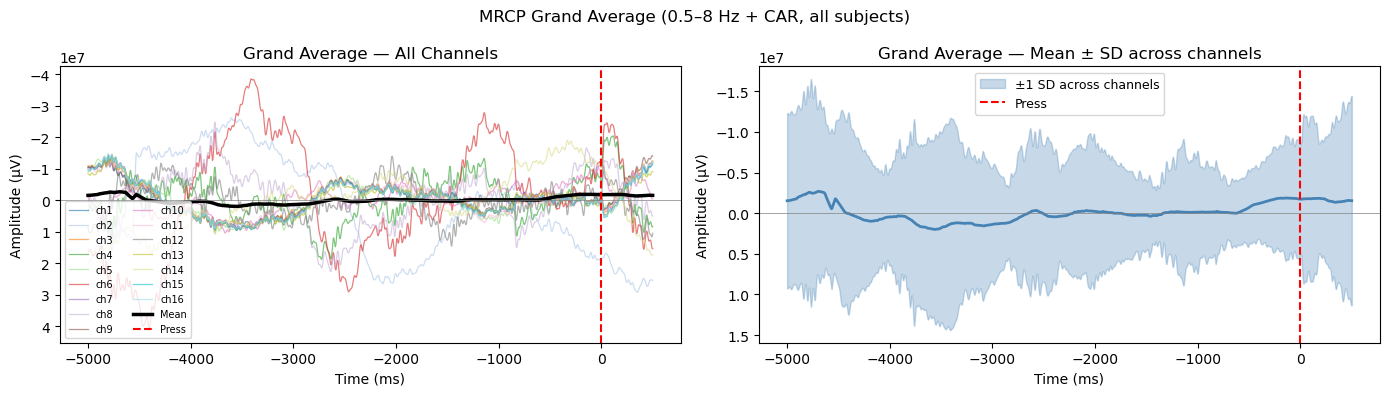

Saved: report/erp_grand_average.png


In [18]:
# ── Grand average across all subjects ─────────────────────────────────────────
grand_avg = np.mean(list(subject_erps.values()), axis=0)  # (T, C)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: all channels
ax = axes[0]
for ch in range(N_CH):
    ax.plot(TIME_AX, grand_avg[:, ch] * 1e6, alpha=0.6, lw=0.9,
            color=cmap[ch], label=EEG_COLS[ch])
ax.plot(TIME_AX, grand_avg.mean(axis=1) * 1e6, color='black', lw=2.5, label='Mean')
ax.axvline(0, color='red', lw=1.5, ls='--', label='Press')
ax.axhline(0, color='gray', lw=0.5)
ax.invert_yaxis()
ax.set_xlabel('Time (ms)'); ax.set_ylabel('Amplitude (µV)')
ax.set_title('Grand Average — All Channels')
ax.legend(loc='lower left', fontsize=7, ncol=2)

# Right: mean ± SD across channels
ax = axes[1]
mean_ch = grand_avg.mean(axis=1) * 1e6
std_ch  = grand_avg.std(axis=1) * 1e6
ax.plot(TIME_AX, mean_ch, color='steelblue', lw=2)
ax.fill_between(TIME_AX, mean_ch - std_ch, mean_ch + std_ch,
                alpha=0.3, color='steelblue', label='±1 SD across channels')
ax.axvline(0, color='red', lw=1.5, ls='--', label='Press')
ax.axhline(0, color='gray', lw=0.5)
ax.invert_yaxis()
ax.set_xlabel('Time (ms)'); ax.set_ylabel('Amplitude (µV)')
ax.set_title('Grand Average — Mean ± SD across channels')
ax.legend(fontsize=9)

fig.suptitle('MRCP Grand Average (0.5–8 Hz + CAR, all subjects)', fontsize=12)
plt.tight_layout()
plt.savefig('report/erp_grand_average.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: report/erp_grand_average.png')

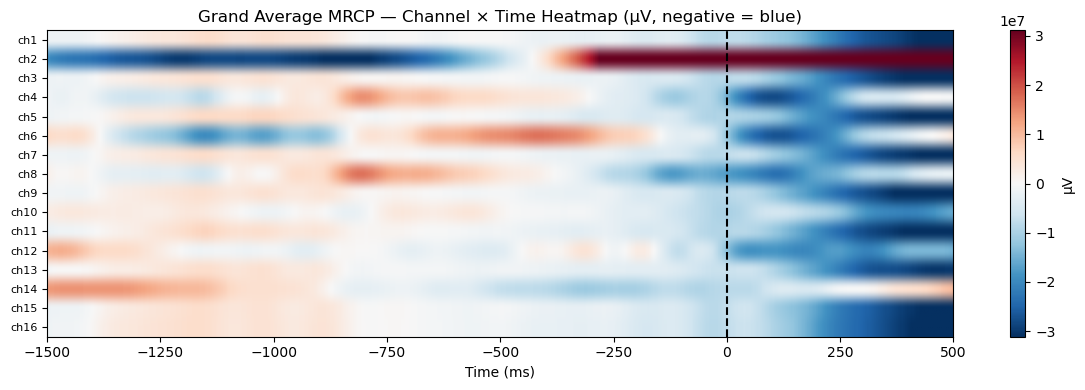

Saved: report/erp_heatmap.png


In [7]:
# ── Heatmap: channels × time, grand average ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

data_uv = grand_avg.T * 1e6   # (C, T)
vmax = np.percentile(np.abs(data_uv), 95)

im = ax.imshow(data_uv, aspect='auto', origin='upper',
               extent=[TIME_AX[0], TIME_AX[-1], N_CH - 0.5, -0.5],
               cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.axvline(0, color='black', lw=1.5, ls='--')
ax.set_yticks(range(N_CH))
ax.set_yticklabels(EEG_COLS, fontsize=8)
ax.set_xlabel('Time (ms)')
ax.set_title('Grand Average MRCP — Channel × Time Heatmap (µV, negative = blue)')
plt.colorbar(im, ax=ax, label='µV')
plt.tight_layout()
plt.savefig('report/erp_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: report/erp_heatmap.png')

In [8]:
# ── Summary statistics ────────────────────────────────────────────────────────
print('Per-subject epoch counts and MRCP peak (mean across channels):')
print(f'{"Subject":>8}  {"Epochs":>7}  {"Peak µV":>9}  {"Peak ms":>9}  {"Trough µV":>10}  {"Trough ms":>10}')
print('-' * 65)
for subj in sorted(subject_erps):
    erp    = subject_erps[subj]
    mean_t = erp.mean(axis=1) * 1e6  # mean across channels
    # MRCP is a negative deflection: find minimum (trough)
    trough_idx = np.argmin(mean_t)
    trough_t   = TIME_AX[trough_idx]
    trough_v   = mean_t[trough_idx]
    # Peak of the movement-monitoring potential (positive, post-press)
    post_mask  = TIME_AX >= 0
    peak_idx   = np.argmax(mean_t[post_mask])
    peak_t     = TIME_AX[post_mask][peak_idx]
    peak_v     = mean_t[post_mask][peak_idx]
    print(f'{subj:>8}  {subject_n[subj]:>7}  {peak_v:>9.3f}  {peak_t:>9.1f}  '
          f'{trough_v:>10.3f}  {trough_t:>10.1f}')

print()
grand_mean_t = grand_avg.mean(axis=1) * 1e6
trough_idx = np.argmin(grand_mean_t)
print(f'Grand average trough: {grand_mean_t[trough_idx]:.3f} µV at {TIME_AX[trough_idx]:.1f} ms')

Per-subject epoch counts and MRCP peak (mean across channels):
 Subject   Epochs    Peak µV    Peak ms   Trough µV   Trough ms
-----------------------------------------------------------------
       0      357      0.387       99.2      -0.417        71.1
      16      301     38.624      183.4     -30.756       355.7

Grand average trough: -14.305 µV at 311.6 ms


In [38]:
import pandas as pd
from tqdm import tqdm

In [342]:
dfs = []
for trial in tqdm(range(10)):
    df_, _ = load_trial(16, 'gng', trial, '../data/subject16/',
                        fs=250, lp=0.5, hp=8.0,
                        decimate=1, car=True,
                        despike_sigma=5, clip_percentile=1)
    onsets = np.concatenate(([0], np.diff(df_['button'].values) > 0))
    df_['button'] = onsets
    dfs.append(df_)
df = pd.concat(dfs, ignore_index=True)
print(df.shape)

100%|██████████| 10/10 [00:01<00:00,  8.87it/s]

(491983, 18)


In [343]:
FS = 250 # Sampling frequency
w_b, w_a = int( 2.5 * FS ), int( .5 * FS ) # Window around button onset (T * fs = N)
delta = w_a + w_b
times = np.arange(-w_b, w_a) / FS  # seconds

In [344]:
EEG_COLS = [f'ch{n}' for n in range(1, 17)]
all_onsets = np.where(df.button)[0]

snipets = []
for onset in all_onsets[100:200]:
    if onset - w_b >= 0 and onset + w_a <= len(df):
        snipets.append(
            df[EEG_COLS].iloc[onset - w_b:onset + w_a].values
        )

snipets = np.stack(snipets)  # (n_epochs, T, 16)
baseline = snipets[:, :w_b, :].mean(axis=1, keepdims=True)
snipets = snipets - baseline
print(snipets.shape)

(100, 750, 16)


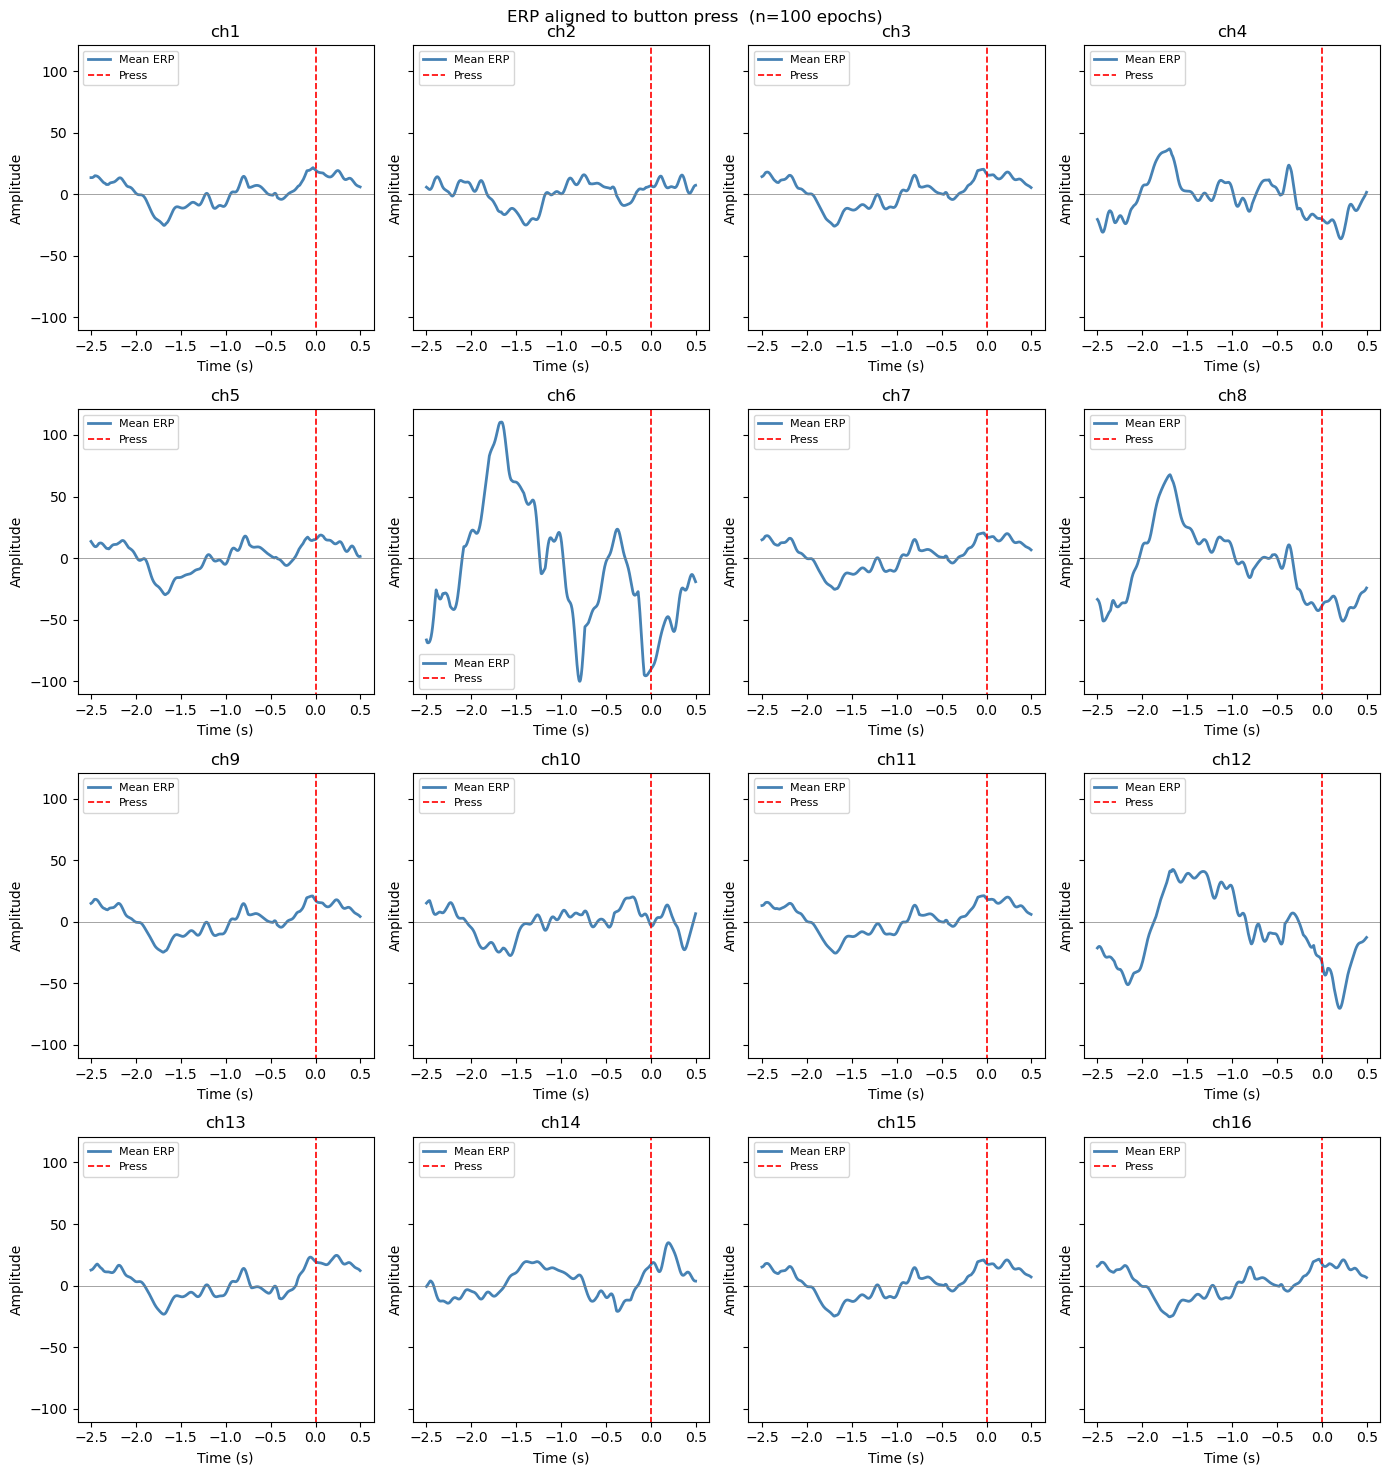

In [345]:
fig, axes = plt.subplots(4, 4, figsize=(14, 15), sharey=True)
ch_names = [f'ch{n}' for n in range(1, 17)]

for ch_idx, ax in enumerate(axes.flatten()):
    erp = snipets[:, :, ch_idx].mean(axis=0)
    ax.plot(times, erp, color='steelblue', lw=2, label='Mean ERP')
    ax.axvline(0, -50, 50, color='red', lw=1.2, ls='--', label='Press')
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.set_title(ch_names[ch_idx])
    ax.legend(fontsize=8)

fig.suptitle(f'ERP aligned to button press  (n={len(snipets)} epochs)', fontsize=12)
plt.tight_layout()
plt.show()

In [346]:
df.ch16.values

array([-2.55515609e-11, -1.73998273e+01, -3.46195887e+01, ...,
       -2.32561085e+01, -1.16865575e+01, -2.68218781e-11])

(750,)

In [332]:
from scipy.stats import mannwhitneyu

# ERP template for ch16 (baseline-corrected average)
x_ = snipets.mean(0)[..., -1]          # (w_b+w_a,)
x_z = x_ - x_.mean()
x_norm = np.linalg.norm(x_z)

def sliding_corr(signal, template_z, template_norm):
    windows  = np.lib.stride_tricks.sliding_window_view(
                   signal.astype(np.float64), len(template_z))
    win_z    = windows - windows.mean(axis=1, keepdims=True)
    win_norm = np.linalg.norm(win_z, axis=1)
    CC = np.full(len(windows), np.nan)
    valid = win_norm > 1e-10
    CC[valid] = (win_z[valid] @ template_z) / (win_norm[valid] * template_norm)
    return CC

# Lags relative to onset (s): negative = before press
LAGS_S = [-3.0, -2.0, -1.0, 0.0]
LAGS   = [int(l * FS) for l in LAGS_S]
lag_cc = {l: [] for l in LAGS_S}

for trial in tqdm(range(10)):
    df_, _ = load_trial(0, 'gng_clean', trial, '../data/subject0/',
                        fs=250, lp=0.5, hp=28.0,
                        decimate=1, car=True,
                        despike_sigma=5, clip_percentile=1)
    df_ = df_.reset_index(drop=True)
    onset_samples = np.where(
        np.concatenate(([0], np.diff(df_['button'].values) > 0))
    )[0]
    CC = sliding_corr(df_['ch16'].values, x_z, x_norm)

    for onset in onset_samples:
        for lag_s, lag in zip(LAGS_S, LAGS):
            k = onset + lag - w_b   # CC index: template press aligns to (onset+lag)
            if 0 <= k < len(CC):
                lag_cc[lag_s].append(CC[k])

print({f'{l:+.0f}s': len(v) for l, v in lag_cc.items()})

100%|██████████| 10/10 [00:03<00:00,  2.69it/s]

{'-3s': 297, '-2s': 297, '-1s': 297, '+0s': 297}


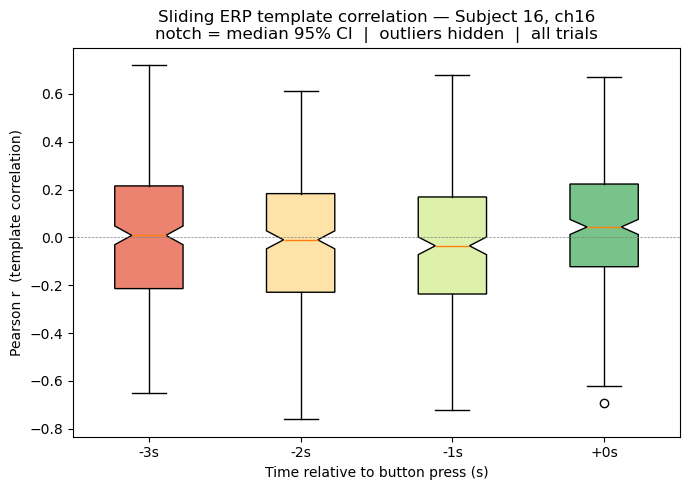

Mann-Whitney U  r(−1s) > r(−3s):  U=40932  p=0.9354  n=[297, 297]
Medians: {'-3s': '0.009', '-2s': '-0.010', '-1s': '-0.035', '+0s': '0.044'}


In [333]:
fig, ax = plt.subplots(figsize=(7, 5))
data   = [lag_cc[l] for l in LAGS_S]
labels = [f'{l:+.0f}s' for l in LAGS_S]

colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(LAGS_S)))
bp = ax.boxplot(data, labels=labels, notch=True,
                showfliers=True, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor((*color[:3], 0.7))

ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel('Time relative to button press (s)')
ax.set_ylabel('Pearson r  (template correlation)')
ax.set_title('Sliding ERP template correlation — Subject 16, ch16\n'
             'notch = median 95% CI  |  outliers hidden  |  all trials')
plt.tight_layout()
plt.show()

# Mann-Whitney: is r at -1s greater than at -3s (baseline)?
stat, p = mannwhitneyu(lag_cc[-1.0], lag_cc[-3.0], alternative='greater')
print(f'Mann-Whitney U  r(−1s) > r(−3s):  U={stat:.0f}  p={p:.4f}  '
      f'n=[{len(lag_cc[-1.0])}, {len(lag_cc[-3.0])}]')
print('Medians:', {f'{l:+.0f}s': f'{np.median(v):.3f}' for l, v in lag_cc.items()})

5169     1.781220e+09
6611     1.781220e+09
7975     1.781220e+09
9355     1.781220e+09
10731    1.781220e+09
12064    1.781220e+09
13460    1.781220e+09
14866    1.781220e+09
16251    1.781220e+09
17650    1.781220e+09
19059    1.781220e+09
20451    1.781220e+09
21850    1.781220e+09
23255    1.781220e+09
24649    1.781220e+09
26047    1.781220e+09
27418    1.781220e+09
28825    1.781220e+09
30212    1.781220e+09
31627    1.781220e+09
33011    1.781220e+09
34419    1.781220e+09
35800    1.781220e+09
36497    1.781220e+09
37234    1.781220e+09
38621    1.781220e+09
40028    1.781220e+09
41421    1.781220e+09
42811    1.781220e+09
44216    1.781220e+09
Name: timestamp, dtype: float64

In [320]:
np.stack(CC).shape

(47043,)